In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
X_df = pd.read_pickle('X_df.pkl')
X_df

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,0.000000,-0.050000,-0.012821,0.000000,0.012903,0.018405,0.024390,0.029851
2022-01-05,0.000000,0.078947,0.077922,0.043796,0.031847,0.030120,0.009524,0.009662
2022-01-06,0.045455,0.097561,0.060241,0.027972,0.024691,0.011696,0.000000,0.000000
2022-01-07,0.043478,-0.044444,-0.011364,0.020408,0.018072,0.017341,0.014151,0.009569
2022-01-10,0.166667,0.069767,0.057471,0.020000,0.011834,0.011364,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2022-12-23,0.002146,0.004310,0.016509,0.018470,0.015915,0.021798,0.020460,0.024129
2022-12-27,0.019272,0.019313,0.002320,0.020725,0.026110,0.024000,0.027569,0.028796
2022-12-28,-0.002101,-0.008421,-0.002315,0.007614,0.010178,0.010417,0.007317,0.012723


In [7]:
len(X_df)

248

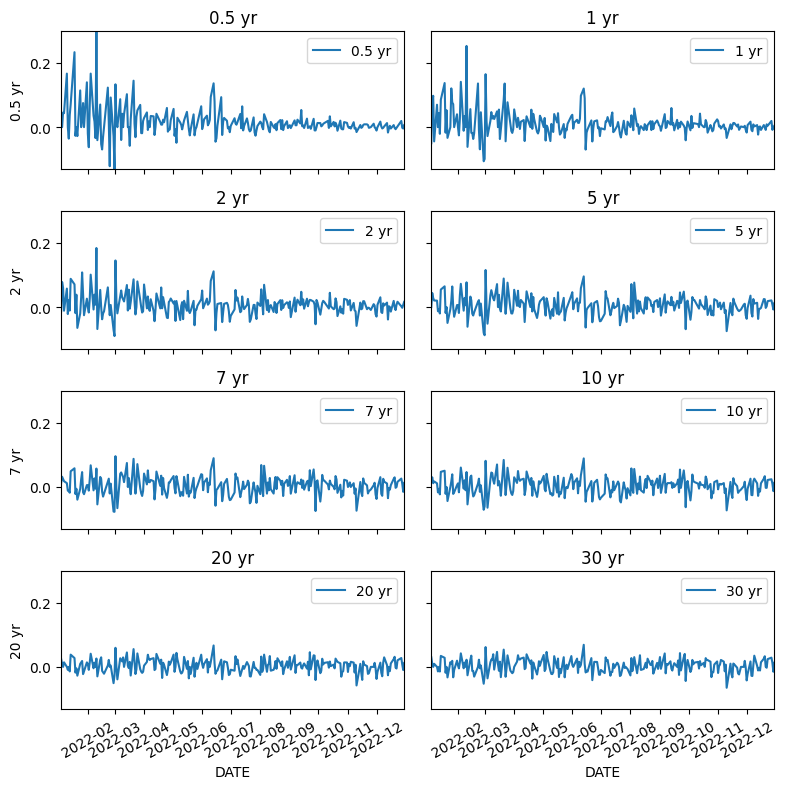

In [21]:
#获取整个X_df的最大值和最小值,统一y轴范围
#第一次提出每一行的最大值最小值,第二次根据上一次的提取出的最大值最小值就是针对全部的
y_min = X_df.min().min()
y_max = X_df.max().max()

fig,axes = plt.subplots(4,2,figsize = (8,8),sharex = True,sharey = True)
axes = axes.flatten()

for i,col in enumerate(X_df.columns):
    sns.lineplot(data = X_df[col],
                 markers = False,
                 dashes = False,#不需要虚线
                 ax = axes[i])
    axes[i].set_title(col)
    #参数:  图例名称为本列名 图例放置在右上角 图例拍成一列(竖行,行方向,好多行的方向)
    axes[i].legend([col],loc = 'upper right',ncol = 1)
    axes[i].set_ylim(y_min,y_max)
    axes[i].set_xlim(X_df.index[0],X_df.index[-1])
    axes[i].tick_params(axis = 'x',rotation = 30)

plt.tight_layout()

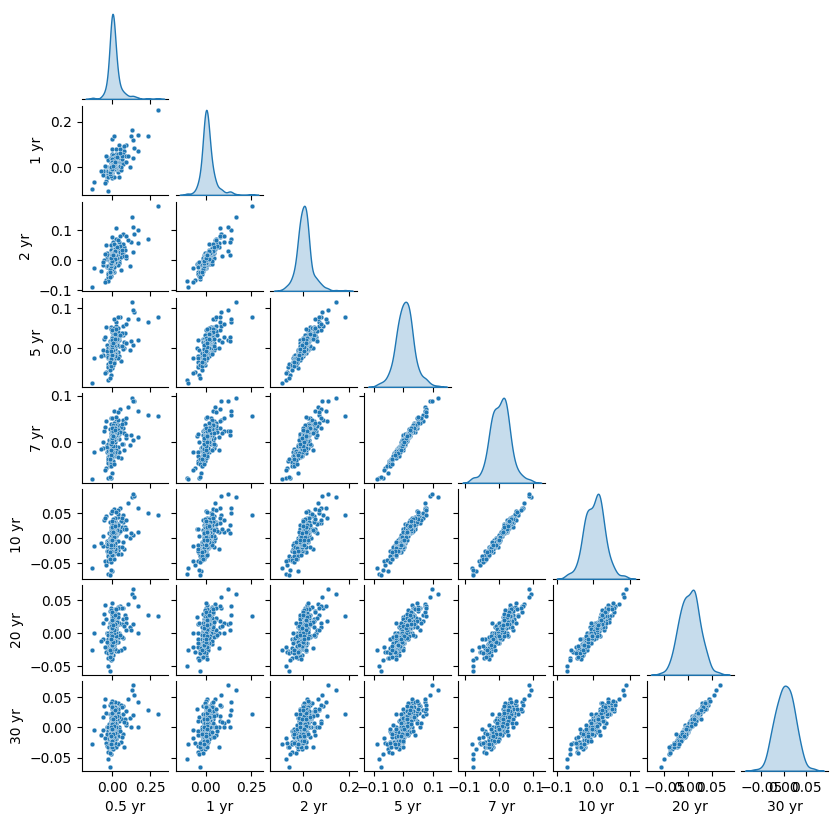

In [27]:
#corner表示角,只绘制下三角 用核密度估计曲线图 给散点图的参数字典告诉size为12
g = sns.pairplot(X_df,corner = True,diag_kind = 'kde',plot_kws = {'s':12})
#配置英寸的大小
g.fig.set_size_inches(8,8)

In [29]:
#中心化

In [33]:
#默认按照列求均值
mean = X_df.mean()
mean = np.array(mean).reshape(-1,1)
mean

array([[0.01336972],
       [0.01074155],
       [0.00756404],
       [0.00477784],
       [0.00421179],
       [0.00387352],
       [0.00305352],
       [0.00297673]])

In [35]:
X_df_c = X_df - X_df.mean()

In [37]:
#协方差矩阵

In [39]:
cov = X_df.cov()

<Axes: >

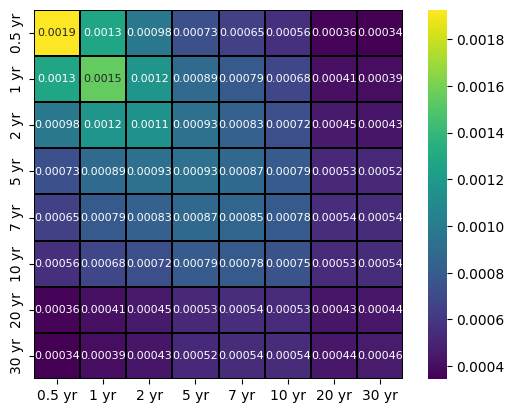

In [41]:
fig,ax = plt.subplots()
sns.heatmap(cov,ax = ax,
            annot = True,
            annot_kws = {'size':8},
            linecolor = 'k',linewidth = '0.1',
            cmap = 'viridis',
            square = True)

In [43]:
#标准差

In [45]:
D_sq = np.sqrt(np.diag(cov))
D_sq

array([0.04388477, 0.03930359, 0.03382721, 0.03043679, 0.02918109,
       0.02732218, 0.02083015, 0.02144493])

In [47]:
D_sq_df = X_df.std()
D_sq_df

0.5 yr    0.043885
1 yr      0.039304
2 yr      0.033827
5 yr      0.030437
7 yr      0.029181
10 yr     0.027322
20 yr     0.020830
30 yr     0.021445
dtype: float64

(0.02, 0.045)

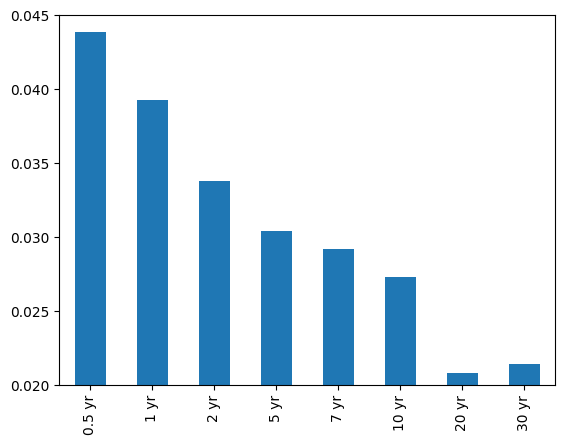

In [49]:
D_sq_df.plot(kind = 'bar') #kind表示图例类型,这里用柱状图
plt.ylim(0.02,0.045)

In [51]:
D = np.diag(D_sq)
D

array([[0.04388477, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.03930359, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.03382721, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.03043679, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.02918109,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.02732218, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.02083015, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.02144493]])

In [53]:
#标准化

In [57]:
Z_df = (X_df - X_df.mean())@np.linalg.inv(D)
Z_df.columns = X_df.columns
Z_df

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,-0.304655,-1.545445,-0.602608,-0.156976,0.297845,0.531853,1.024319,1.253164
2022-01-05,-0.304655,1.735359,2.079924,1.281928,0.947029,0.960647,0.310621,0.311733
2022-01-06,0.731115,2.208944,1.557235,0.762044,0.701810,0.286302,-0.146591,-0.138808
2022-01-07,0.686082,-1.404096,-0.559540,0.513534,0.474982,0.492915,0.532758,0.307422
2022-01-10,3.493170,1.501794,1.475357,0.500124,0.261215,0.274141,-0.146591,-0.138808
...,...,...,...,...,...,...,...,...
2022-12-23,-0.255756,-0.163629,0.264444,0.449844,0.401059,0.656055,0.835656,0.986338
2022-12-27,0.134494,0.218091,-0.155019,0.523956,0.750413,0.736635,1.176919,1.203971
2022-12-28,-0.352527,-0.487554,-0.292039,0.093189,0.204459,0.239481,0.204682,0.454462


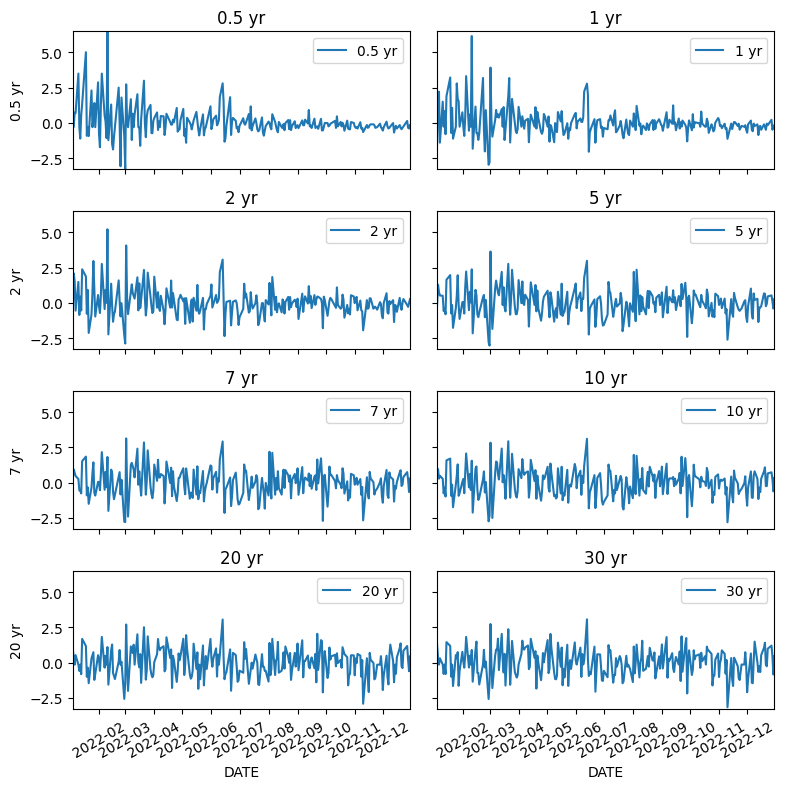

In [67]:
y_min = Z_df.min().min()
y_max = Z_df.max().max()

fig,axes = plt.subplots(4,2,figsize = (8,8),sharex = True,sharey = True)
axes = axes.flatten()

for i,col in enumerate(Z_df.columns):
    sns.lineplot(data = Z_df[col],
                 markers = False,
                 dashes = False,
                 ax = axes[i])
    axes[i].set_title(col)
    axes[i].legend([col],loc = 'upper right',ncol = 1)
    axes[i].set_ylim(y_min,y_max)
    axes[i].set_xlim(Z_df.index[0],Z_df.index[-1])
    axes[i].tick_params(axis = 'x',rotation = 30)
#调整布局防止重叠
plt.tight_layout()

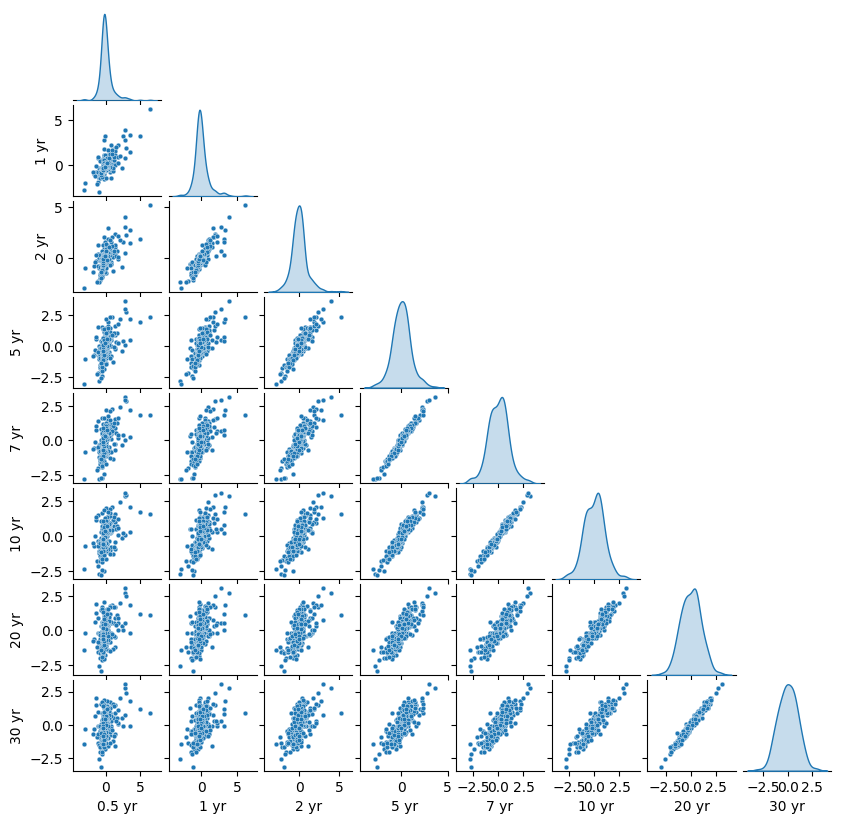

In [69]:
g = sns.pairplot(Z_df,corner = True,diag_kind = 'kde',plot_kws = {'s':12})
g.fig.set_size_inches(8,8)

In [71]:
#线性相关系数矩阵

In [73]:
P = X_df.corr()
P

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
0.5 yr,1.000000,0.741326,0.658817,0.547214,0.508018,0.469002,0.395009,0.365413
1 yr,0.741326,1.000000,0.877098,0.741927,0.685748,0.633442,0.497752,0.466968
2 yr,0.658817,0.877098,1.000000,0.899742,0.838473,0.782254,0.637459,0.593849
5 yr,0.547214,0.741927,0.899742,1.000000,0.982671,0.951628,0.833816,0.793134
7 yr,0.508018,0.685748,0.838473,0.982671,1.000000,0.983504,0.894960,0.857845
10 yr,0.469002,0.633442,0.782254,0.951628,0.983504,1.000000,0.939536,0.915748
20 yr,0.395009,0.497752,0.637459,0.833816,0.894960,0.939536,1.000000,0.981736
30 yr,0.365413,0.466968,0.593849,0.793134,0.857845,0.915748,0.981736,1.000000
